<a href="https://colab.research.google.com/github/Josembp18/DataScience/blob/main/C_8_Regresion_Lineal_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importación de librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Configuración para mejores gráficos
plt.style.use('default')
np.random.seed(42)  # Para reproducibilidad

# =============================================================================
# 1. GENERACIÓN DE DATOS DE EJEMPLO
# =============================================================================
print("=== GENERANDO DATOS DE EJEMPLO ===")

# Crear datos sintéticos: y = 2x + 1 + ruido
x = np.linspace(0, 10, 50)  # 50 puntos entre 0 y 10
ruido = np.random.normal(0, 1, 50)  # Ruido aleatorio
y = 2 * x + 1 + ruido  # Relación lineal con ruido

print(f"Variable independiente (X): {x[:5]}...")  # Primeros 5 valores
print(f"Variable dependiente (y): {y[:5]}...")
print(f"Forma de X: {x.shape}")

=== GENERANDO DATOS DE EJEMPLO ===
Variable independiente (X): [0.         0.20408163 0.40816327 0.6122449  0.81632653]...
Variable dependiente (y): [1.49671415 1.26989896 2.46401507 3.74751965 2.39849969]...
Forma de X: (50,)


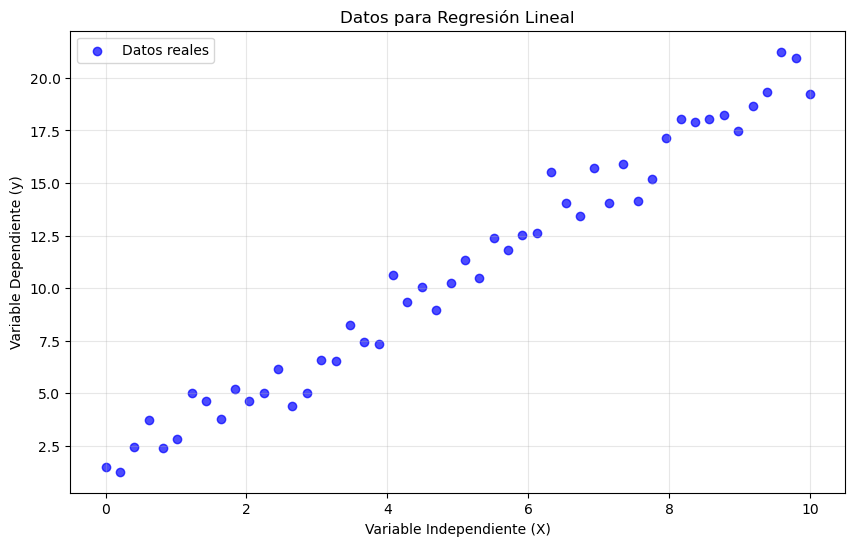

In [ ]:
# =============================================================================
# 2. VISUALIZACIÓN DE LOS DATOS
# =============================================================================
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.7, color='blue', label='Datos reales')
plt.xlabel('Variable Independiente (X)')
plt.ylabel('Variable Dependiente (y)')
plt.title('Datos para Regresión Lineal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
# =============================================================================
# 3. PREPARACIÓN DE LOS DATOS
# =============================================================================
print("\n=== PREPARANDO DATOS ===")

# La regresión lineal de sklearn espera X en formato 2D
X = x.reshape(-1, 1)  # Convertir de 1D a 2D

# Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Datos de entrenamiento: {X_train.shape[0]} muestras")
print(f"Datos de prueba: {X_test.shape[0]} muestras")



=== PREPARANDO DATOS ===
Datos de entrenamiento: 40 muestras
Datos de prueba: 10 muestras


In [ ]:
# =============================================================================
# 4. CREACIÓN Y ENTRENAMIENTO DEL MODELO
# =============================================================================
print("\n=== ENTRENANDO EL MODELO ===")

# Crear instancia del modelo de regresión lineal
modelo = LinearRegression()

# Entrenar el modelo con los datos de entrenamiento
modelo.fit(X_train, y_train)

print("✅ Modelo entrenado exitosamente!")


=== ENTRENANDO EL MODELO ===
✅ Modelo entrenado exitosamente!


In [ ]:
# =============================================================================
# 5. OBTENER PARÁMETROS DEL MODELO
# =============================================================================
print("\n=== PARÁMETROS DEL MODELO ===")

# Coeficiente (pendiente de la recta)
pendiente = modelo.coef_[0]
intercepto = modelo.intercept_

print(f"Pendiente (coeficiente): {pendiente:.4f}")
print(f"Intercepto: {intercepto:.4f}")
print(f"Ecuación de la recta: y = {pendiente:.4f}x + {intercepto:.4f}")


=== PARÁMETROS DEL MODELO ===
Pendiente (coeficiente): 1.9173
Intercepto: 1.2322
Ecuación de la recta: y = 1.9173x + 1.2322


In [ ]:
# =============================================================================
# 6. REALIZAR PREDICCIONES
# =============================================================================
print("\n=== REALIZANDO PREDICCIONES ===")

# Predecir con datos de prueba
y_pred = modelo.predict(X_test)

print("Predicciones vs Real:")
for i in range(min(5, len(y_test))):  # Mostrar primeras 5 predicciones
    print(f"Real: {y_test[i]:.2f} - Predicho: {y_pred[i]:.2f}")


=== REALIZANDO PREDICCIONES ===
Predicciones vs Real:
Real: 4.39 - Predicho: 6.32
Real: 17.12 - Predicho: 16.49
Real: 12.64 - Predicho: 12.97
Real: 18.65 - Predicho: 18.84
Real: 8.25 - Predicho: 7.88


In [ ]:
# =============================================================================
# 7. EVALUACIÓN DEL MODELO
# =============================================================================
print("\n=== EVALUANDO EL MODELO ===")

# Calcular métricas de evaluación
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R² (Coeficiente de determinación): {r2:.4f}")
print(f"MSE (Error Cuadrático Medio): {mse:.4f}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.4f}")

# Interpretación de R²
print(f"\n📊 Interpretación de R²: {r2*100:.1f}% de la variabilidad en y es explicada por X")


=== EVALUANDO EL MODELO ===
R² (Coeficiente de determinación): 0.9676
MSE (Error Cuadrático Medio): 0.8049
RMSE (Raíz del Error Cuadrático Medio): 0.8972

📊 Interpretación de R²: 96.8% de la variabilidad en y es explicada por X


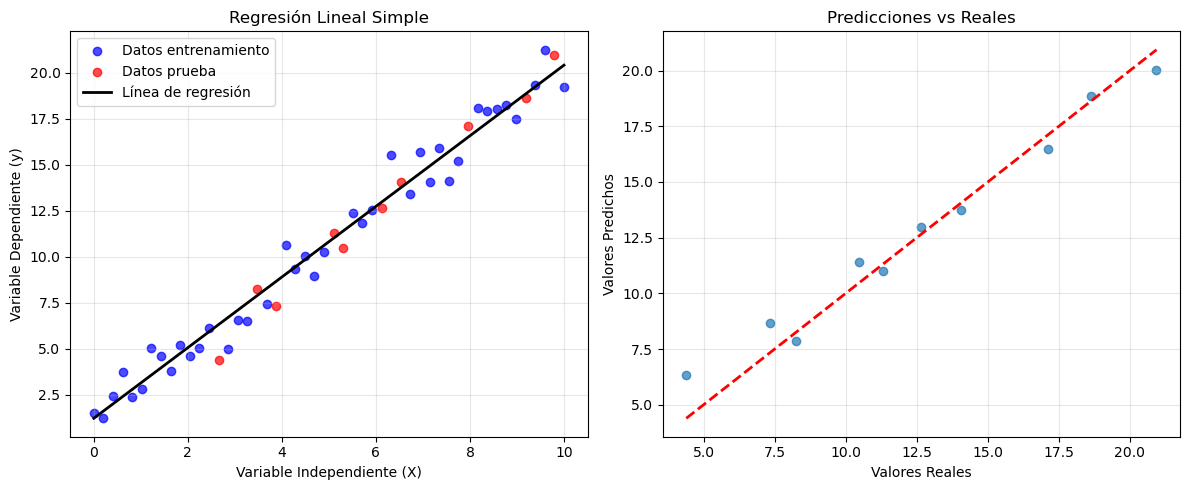

In [ ]:
# =============================================================================
# 8. VISUALIZACIÓN DE RESULTADOS
# =============================================================================
plt.figure(figsize=(12, 5))

# Subplot 1: Datos y línea de regresión
plt.subplot(1, 2, 1)
plt.scatter(X_train, y_train, color='blue', alpha=0.7, label='Datos entrenamiento')
plt.scatter(X_test, y_test, color='red', alpha=0.7, label='Datos prueba')

# Línea de regresión
x_line = np.linspace(0, 10, 100).reshape(-1, 1)
y_line = modelo.predict(x_line)
plt.plot(x_line, y_line, color='black', linewidth=2, label='Línea de regresión')

plt.xlabel('Variable Independiente (X)')
plt.ylabel('Variable Dependiente (y)')
plt.title('Regresión Lineal Simple')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Predicciones vs Valores reales
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.title('Predicciones vs Reales')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:

# =============================================================================
# 9. PREDICCIÓN CON NUEVOS DATOS
# =============================================================================
print("\n=== PREDICCIÓN CON NUEVOS DATOS ===")

# Ejemplo de predicción con nuevos valores
nuevos_x = np.array([2.5, 5.0, 7.5, 11.0]).reshape(-1, 1)
predicciones = modelo.predict(nuevos_x)

print("Predicciones para nuevos valores de X:")
for i, (x_val, y_pred_val) in enumerate(zip(nuevos_x.flatten(), predicciones)):
    print(f"X = {x_val:.1f} → y_pred = {y_pred_val:.2f}")




=== PREDICCIÓN CON NUEVOS DATOS ===
Predicciones para nuevos valores de X:
X = 2.5 → y_pred = 6.03
X = 5.0 → y_pred = 10.82
X = 7.5 → y_pred = 15.61
X = 11.0 → y_pred = 22.32


In [ ]:
# =============================================================================
# 10. INTERPRETACIÓN FINAL
# =============================================================================
print("\n" + "="*50)
print("RESUMEN Y INTERPRETACIÓN")
print("="*50)

print(f"""
📈 LA REGRESIÓN LINEAL EXPLICA:

• Relación entre variables: Por cada unidad que aumenta X,
  Y aumenta aproximadamente {pendiente:.2f} unidades.

• Punto de inicio: Cuando X = 0, Y vale aproximadamente {intercepto:.2f}

• Calidad del modelo: El R² de {r2:.3f} indica que el modelo explica
  {r2*100:.1f}% de la variabilidad en los datos.

• Error promedio: Las predicciones tienen un error promedio de ±{rmse:.2f} unidades.

💡 APLICACIONES PRÁCTICAS:
- Predecir ventas basadas en gastos en publicidad
- Estimar precios de casas según su tamaño
- Pronosticar calificaciones según horas de estudio
""")


RESUMEN Y INTERPRETACIÓN

📈 LA REGRESIÓN LINEAL EXPLICA:

• Relación entre variables: Por cada unidad que aumenta X, 
  Y aumenta aproximadamente 1.92 unidades.

• Punto de inicio: Cuando X = 0, Y vale aproximadamente 1.23

• Calidad del modelo: El R² de 0.968 indica que el modelo explica 
  96.8% de la variabilidad en los datos.

• Error promedio: Las predicciones tienen un error promedio de ±0.90 unidades.

💡 APLICACIONES PRÁCTICAS:
- Predecir ventas basadas en gastos en publicidad
- Estimar precios de casas según su tamaño
- Pronosticar calificaciones según horas de estudio

